# Priors

Testing the impact of enforcing priors on model predictions, for both label bounds and a sum prior.

In [1]:
# imports 
import matplotlib.pyplot as plt
plt.style.use('thesis')
import numpy as np
from scipy.stats import median_abs_deviation as mad

## Label Bounds

In [3]:
# comparing no bounds, log, enforced bounds
base = '/avatar/vmehta/sfh_1000_3bins_20260402_162314/bounds-testing'
basic_pred = np.load(f'{base}/basic-model/snr1000_pred.npy')
basic_true = np.load(f'{base}/basic-model/snr1000_true.npy')
log_pred = np.load(f'{base}/log-model/snr1000_pred.npy')
log_true = np.load(f'{base}/log-model/snr1000_true.npy')
bounds_pred = np.load(f'{base}/bounds-model/snr1000_pred.npy')
bounds_true = np.load(f'{base}/bounds-model/snr1000_true.npy')
res_bounds = bounds_true - bounds_pred
res_log = log_true - log_pred

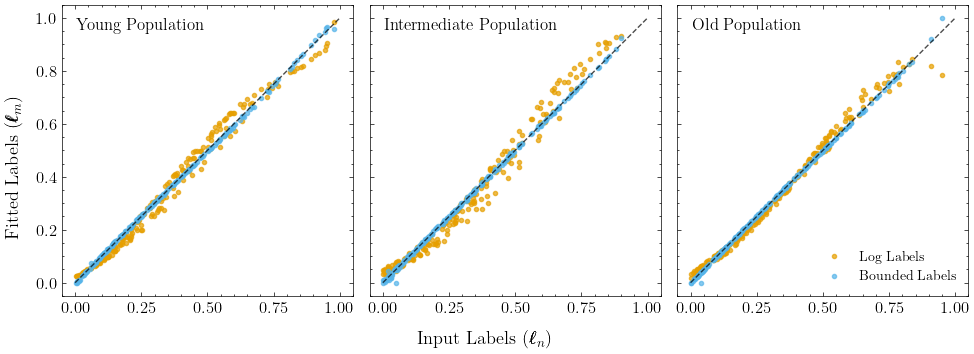

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3.7), sharex=True, sharey=True)

for i in range(3):
    ax[i].plot(log_true[:, i], log_pred[:, i], '.', alpha=0.7, label='Log Labels')
    ax[i].plot(bounds_true[:, i], bounds_pred[:, i], '.', alpha=0.7, label='Bounded Labels')
    ax[i].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax[i].set_box_aspect(1)

ax[0].text(0.05, 0.95, 'Young Population', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.05, 0.95, 'Intermediate Population', transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[2].text(0.05, 0.95, 'Old Population', transform=ax[2].transAxes, fontsize=12, verticalalignment='top')
ax[2].legend(loc='lower right', fontsize=10)

fig.supxlabel(r'Input Labels $(\pmb\ell_n)$')
fig.supylabel(r'Fitted Labels $(\pmb\ell_m)$')
plt.tight_layout()
plt.savefig('/home/vmehta/honours-project/thesis/figures/logvslin.pdf', format='pdf')
plt.show()

In [7]:
print(f"MAD for log-models: {mad(res_log, axis=0)}")
print(f"Percentage of points outside 3MAD: {(np.abs(res_log) > 3*mad(res_log, axis=0)).sum(axis=0)}")
print(f"MAD for linear-models: {mad(res_bounds, axis=0)}")
print(f"Percentage of points outside 3MAD: {(np.abs(res_bounds) > 3*mad(res_bounds, axis=0)).sum(axis=0)}")

MAD for log-models: [0.02037815 0.02507436 0.01390223]
Percentage of points outside 3MAD: [ 1 15 12]
MAD for linear-models: [0.00295847 0.00225373 0.00149192]
Percentage of points outside 3MAD: [14 12 12]


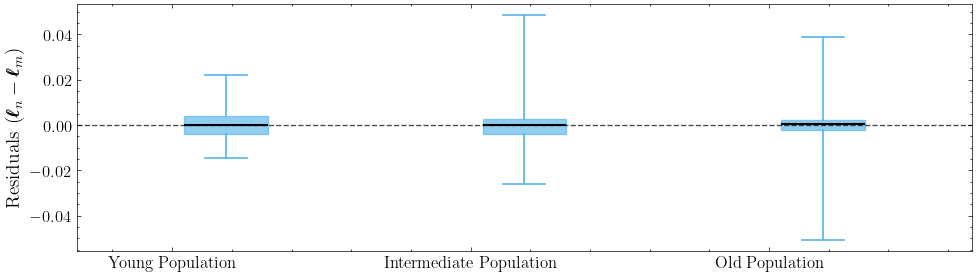

In [47]:
# box-and-whisker plot of residuals for the three populations
labels = ['Young Population', 'Intermediate Population', 'Old Population']
positions = np.arange(len(labels))
width = 0.28
gap = 0.08
offset = width / 2 + gap / 2

fig, ax = plt.subplots(figsize=(10, 3))

log_data = [res_log[:, i] for i in range(3)]
bounds_data = [res_bounds[:, i] for i in range(3)]

def percentile_box_stats(data):
    data = np.asarray(data)
    q16, q50, q84 = np.percentile(data, [16, 50, 84])
    return dict(
        med=q50,
        q1=q16,
        q3=q84,
        whislo=np.min(data),
        whishi=np.max(data),
        fliers=np.array([]),
    )

log_stats = [percentile_box_stats(data) for data in log_data]
bounds_stats = [percentile_box_stats(data) for data in bounds_data]

# bp_log = ax.bxp(
#     log_stats,
#     positions=positions - offset,
#     widths=width,
#     showfliers=False,
#     patch_artist=True,
#     boxprops=dict(facecolor='C0', alpha=0.65),
#     whiskerprops=dict(color='C0', linewidth=1.2),
#     capprops=dict(color='C0', linewidth=1.2),
#     medianprops=dict(color='black', linewidth=1.5),
# )

bp_bounds = ax.bxp(
    bounds_stats,
    positions=positions + offset,
    widths=width,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='C1', alpha=0.65),
    whiskerprops=dict(color='C1', linewidth=1.2),
    capprops=dict(color='C1', linewidth=1.2),
    medianprops=dict(color='black', linewidth=1.5),
)

# for box in bp_log['boxes']:
#     box.set_edgecolor('C0')
for box in bp_bounds['boxes']:
    box.set_edgecolor('C1')

ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel(r'Residuals $(\pmb\ell_n - \pmb\ell_m)$')
#ax.legend([bp_log['boxes'][0], bp_bounds['boxes'][0]], ['Log Labels', 'Bounded Labels'], loc='upper right')

plt.tight_layout()
plt.show()

## Sum Prior

In [29]:
# comparing no bounds, log, enforced bounds
base = '/avatar/vmehta/sfh_1000_3bins_20260402_162314/sumprior-testing'
noprior_pred = np.load(f'{base}/no-prior/snr1000_pred.npy')
noprior_true = np.load(f'{base}/no-prior/snr1000_true.npy')
pred_1 = np.load(f'{base}/0_1-prior/snr1000_pred.npy')
true_1 = np.load(f'{base}/0_1-prior/snr1000_true.npy')
pred_0_1 = np.load(f'{base}/0_0_1-prior/snr1000_pred.npy')
true_0_1 = np.load(f'{base}/0_0_1-prior/snr1000_true.npy')
pred_0_0_1 = np.load(f'{base}/0_0_0_1-prior/snr1000_pred.npy')
true_0_0_1 = np.load(f'{base}/0_0_0_1-prior/snr1000_true.npy')

## Accuracy
How does enforcing priors impact the accuracy of predicted SFH?

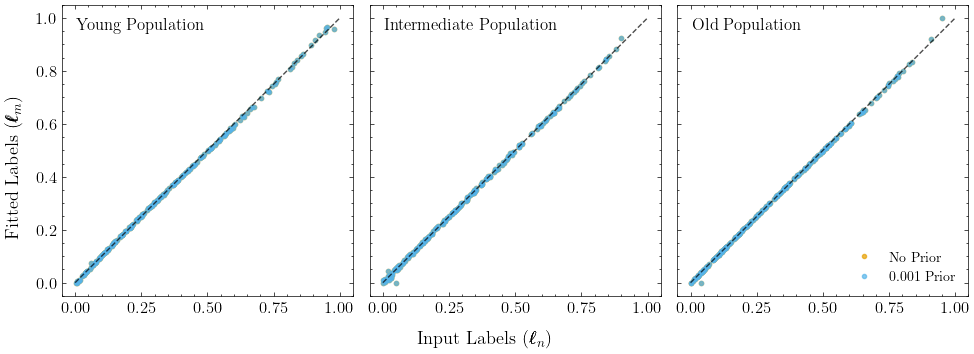

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3.7), sharex=True, sharey=True)

for i in range(3):
    ax[i].plot(noprior_true[:, i], noprior_pred[:, i], '.', alpha=0.7, label='No Prior')
    #ax[i].plot(true_1[:, i], pred_1[:, i], '.', alpha=0.7, label='0.1 Prior')
    #ax[i].plot(true_0_1[:, i], pred_0_1[:, i], '.', alpha=0.7, label='0.01 Prior')
    ax[i].plot(true_0_0_1[:, i], pred_0_0_1[:, i], '.', alpha=0.7, label='0.001 Prior')
    ax[i].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax[i].set_box_aspect(1)

ax[0].text(0.05, 0.95, 'Young Population', transform=ax[0].transAxes, fontsize=12, verticalalignment='top')
ax[1].text(0.05, 0.95, 'Intermediate Population', transform=ax[1].transAxes, fontsize=12, verticalalignment='top')
ax[2].text(0.05, 0.95, 'Old Population', transform=ax[2].transAxes, fontsize=12, verticalalignment='top')
ax[2].legend(loc='lower right', fontsize=10)

fig.supxlabel(r'Input Labels $(\pmb\ell_n)$')
fig.supylabel(r'Fitted Labels $(\pmb\ell_m)$')
plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/logvslin.pdf', format='pdf')
plt.show()

## Precision
How does enforcing priors impact the label sums? Plot histograms for the sum of all labels.

In [30]:
def plot_hist(data, ax=None, bins=100, focus_percentile=90.0, color='C0', alpha=0.7, density=False, plotmean=True, plotmed=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    data = np.asarray(data)
    data = data[np.isfinite(data)]
    if data.size == 0:
        raise ValueError('data is empty after filtering non-finite values')

    lowp = (100 - focus_percentile) / 2.0
    highp = 100 - lowp
    vmin, vmax = np.percentile(data, [lowp, highp])

    clipped = data[(data >= vmin) & (data <= vmax)]
    ax.hist(clipped, bins=bins, color=color, alpha=alpha, density=density)
    if plotmean:
        ax.axvline(np.mean(data), color='k', linestyle=':', linewidth=1, label='Mean')
    if plotmed:
        ax.axvline(np.median(data), color='k', linestyle='--', linewidth=1, label='Median')

    return ax

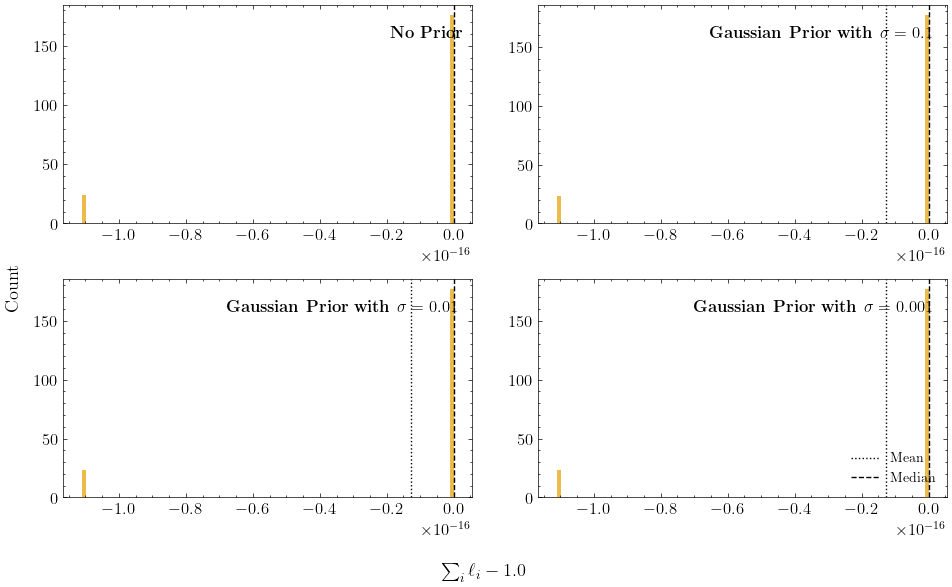

In [31]:
# having a look at some of the distributions
label_sum_none = np.sum(noprior_pred, axis=1)
label_sum_0_1 = np.sum(pred_1, axis=1)
label_sum_0_0_1 = np.sum(pred_0_1, axis=1)
label_sum_0_0_0_1 = np.sum(pred_0_0_1, axis=1)

fig, ax = plt.subplots(2, 2, figsize=(10, 6))
plot_hist(label_sum_none-1, focus_percentile=100, ax=ax[0, 0], plotmean=False)
plot_hist(label_sum_0_1-1, focus_percentile=100, ax=ax[0, 1])
plot_hist(label_sum_0_0_1-1, focus_percentile=100, ax=ax[1, 0])
plot_hist(label_sum_0_0_0_1-1, focus_percentile=100, ax=ax[1, 1])
fig.supxlabel('$\\sum_i\\ell_i-1.0$')
fig.supylabel('Count')
ax[1,1].legend(loc='lower right', fontsize=10)
ax[0,0].text(0.8, 0.9, '\\textbf{No Prior}', transform=ax[0,0].transAxes, fontsize=12, verticalalignment='top')
ax[0,1].text(0.42, 0.9, '\\textbf{Gaussian Prior with $\\sigma=0.1$}', transform=ax[0,1].transAxes, fontsize=12, verticalalignment='top')
ax[1,0].text(0.4, 0.9, '\\textbf{Gaussian Prior with $\\sigma=0.01$}', transform=ax[1,0].transAxes, fontsize=12, verticalalignment='top')
ax[1,1].text(0.38, 0.9, '\\textbf{Gaussian Prior with $\\sigma=0.001$}', transform=ax[1,1].transAxes, fontsize=12, verticalalignment='top')
# ax[0,1].ticklabel_format(axis='x', style='sci', scilimits=(0,0))
# ax[0,1].xaxis.get_offset_text().set_visible(False)
# ax[0,1].text(0.97, -0.01, '$\\times10^{-4}$', transform=ax[0,1].transAxes, fontsize=12, verticalalignment='top')
# ax[1,0].xaxis.get_offset_text().set_visible(False)
# ax[1,0].text(0.97, -0.01, '$\\times10^{-6}$', transform=ax[1,0].transAxes, fontsize=12, verticalalignment='top')
# ax[1,1].xaxis.get_offset_text().set_visible(False)
# ax[1,1].text(0.97, -0.01, '$\\times10^{-8}$', transform=ax[1,1].transAxes, fontsize=12, verticalalignment='top')

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/prior_histograms.pdf', format='pdf')

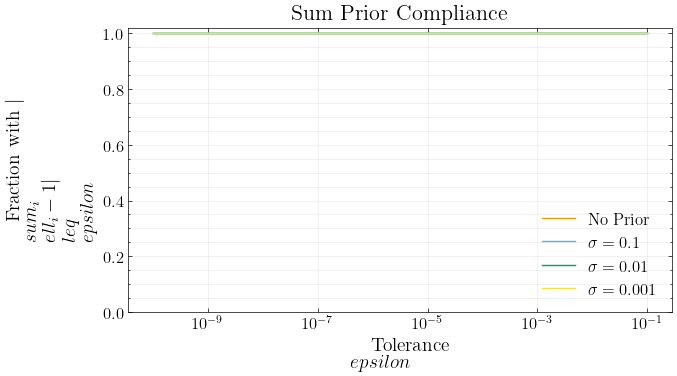

In [35]:
# tolerance curve for the sum prior
resid_none = np.abs(label_sum_none - 1)
resid_0_1 = np.abs(label_sum_0_1 - 1)
resid_0_0_1 = np.abs(label_sum_0_0_1 - 1)
resid_0_0_0_1 = np.abs(label_sum_0_0_0_1 - 1)

epsilons = np.logspace(-10, -1, 200)

fig, ax = plt.subplots(figsize=(7, 4))

for resid, label, color in [
    (resid_none, 'No Prior', 'C0'),
    (resid_0_1, '$\\sigma=0.1$', 'C1'),
    (resid_0_0_1, '$\\sigma=0.01$', 'C2'),
    (resid_0_0_0_1, '$\\sigma=0.001$', 'C3'),
]:
    fraction_within = [(resid <= eps).mean() for eps in epsilons]
    ax.plot(epsilons, fraction_within, label=label, color=color)

ax.set_xscale('log')
ax.set_ylim(0, 1.02)
ax.set_xlabel(r'Tolerance $\\epsilon$')
ax.set_ylabel(r'Fraction with $|\\sum_i \\ell_i - 1| \\leq \\epsilon$')
ax.set_title('Sum Prior Compliance')
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.show()